In [21]:
import pandas as pd
import numpy as np

import warnings

warnings.filterwarnings("ignore")

In [33]:
import subprocess

REQUESTS_FILE = "data/requests/ann-arbor.parquet"

FLEET_SIZES = (7500, 10000, 12500, 15000)

pax2 = 1.0
pax4 = 0.0

args = ["./sim"]
for fleet_size in FLEET_SIZES:
    with open(f"data/sim_configs/ann-arbor-{fleet_size}.txt", "w") as f:
        f.write(f"length: {24 * 7 * 3600}\n")
        f.write(f"requests: {REQUESTS_FILE}\n")
        f.write(f"riders: data/riders/ann-arbor-{fleet_size}.parquet\n")
        f.write(f"output: output/ann-arbor-{fleet_size}-{pax2}-{pax4}\n")

        f.write(f"frac_2_seater: {pax2}\n")
        f.write(f"frac_4_seater: {pax4}\n")

    args.append(f"ann-arbor-{fleet_size}")

subprocess.run(["cmake", "--build", "cmake-build-release", "--target", "sim", "-j", "8"], check=True)
subprocess.run(args, check=True)

[ 12%] Built target tqdm
[ 50%] Built target h3
[ 56%] Built target pandas
[ 62%] Building CXX object CMakeFiles/sim.dir/src/allocation/RiderSource.cpp.o
[ 62%] Building CXX object CMakeFiles/sim.dir/src/allocation/AllocationEngine.cpp.o
[ 62%] Building CXX object CMakeFiles/sim.dir/src/main.cpp.o
[ 68%] Building CXX object CMakeFiles/sim.dir/src/riders/Rider.cpp.o
[ 68%] Building CXX object CMakeFiles/sim.dir/src/riders/FleetStats.cpp.o
[ 68%] Building CXX object CMakeFiles/sim.dir/src/riders/RiderBattery.cpp.o
[ 75%] Building CXX object CMakeFiles/sim.dir/src/riders/RiderHex.cpp.o
[ 75%] Building CXX object CMakeFiles/sim.dir/src/riders/RiderPAX.cpp.o
[ 75%] Linking CXX executable /Users/bhavyemathur/Desktop/Academics/College/UMich/IOE/ev-sim/sim
[100%] Built target sim
...launching 4 threads
reading data/requests/ann-arbor.parquet
reading data/requests/ann-arbor.parquet
reading data/requests/ann-arbor.parquet
reading data/requests/ann-arbor.parquet
reading data/riders/ann-arbor-1000

[                                                  ]   0% | [ 0s< 0s]

reading data/riders/ann-arbor-7500.parquet
reading data/riders/ann-arbor-15000.parquet
reading data/riders/ann-arbor-12500.parquet


[##################################################] 100% | [72s< 0s]
[##################################################] 100% | [73s< 0s]
[##################################################] 100% | [80s< 0s]
[##################################################] 100% | [89s< 0s]


simulation complete
...saving fleet statistics (count=676)
...saving statistics (count=3346447)
simulation complete
...saving fleet statistics (count=677)
...saving statistics (count=3346447)
simulation complete
...saving fleet statistics (count=676)
...saving statistics (count=3346447)
simulation complete
...saving fleet statistics (count=676)
...saving statistics (count=3346447)
Elapsed time: 111141 milliseconds



CompletedProcess(args=['./sim', 'ann-arbor-7500', 'ann-arbor-10000', 'ann-arbor-12500', 'ann-arbor-15000'], returncode=0)

In [28]:
def load_results(requests_file: str, output_file: str):
    requests = pd.read_parquet(requests_file)
    output = pd.read_parquet(f"{output_file}.parquet")

    fleet_output = pd.read_parquet(f"{output_file}-fleet.parquet")
    fleet_output.set_index("timestamp", inplace=True)
    fleet_output = fleet_output.add_prefix("n_")

    output = requests.merge(output, left_index=True, right_index=True, validate="1:1")

    all_output = output.copy()
    output = output[output["completed"]]

    output["response_time"] = output["arrived_pickup_at"] - output["created_at"]
    output["fm_time"] = output["arrived_pickup_at"] - output["start_at"]
    output["pickup_time"] = output["pickedup_at"] - output["arrived_pickup_at"]
    output["lm_time"] = output["arrived_drop_at"] - output["pickedup_at"]
    output["drop_time"] = output["completed_at"] - output["arrived_drop_at"]

    return all_output, output, fleet_output


def compute_stats(all_output, output):
    mean_fm_dist = output["fm_dist"].mean()  # km
    mean_fm_time = output["fm_time"].mean() / 60  # mins
    mean_fm_speed = mean_fm_dist / (mean_fm_time / 60)  # kmph

    mean_lm_dist = output["lm_dist"].mean()  # km
    mean_lm_time = output["lm_time"].mean() / 60  # mins
    mean_lm_speed = mean_lm_dist / (mean_lm_time / 60)  # kmph

    return {
        "total": len(all_output),
        "completed": len(output),
        "dropped": len(all_output) - len(output),
        "service_level": 100 * len(output) / len(all_output),  # %

        "fm_dist": mean_fm_dist,
        "fm_time": mean_fm_time,
        "fm_speed": mean_fm_speed,

        "lm_dist": mean_lm_dist,
        "lm_time": mean_lm_time,
        "lm_speed": mean_lm_speed,

        "response_time": output["response_time"].mean() / 60,  # mins
        "pickup_time": output["pickup_time"].mean() / 60,  # mins
        "drop_time": output["drop_time"].mean() / 60,  # mins

        "pax": output["pax"].mean(),
    }


fleet_size = 10000
pax2 = 1.0
pax4 = 0.0

all_output, output, fleet_output = load_results(REQUESTS_FILE, f"output/ann-arbor-{fleet_size}-{pax2}-{pax4}")
stats = compute_stats(all_output, output)

print(f"Completed: {len(output)} / {len(all_output)} or {stats['service_level']:.2f}%")
print(f"           ({stats['dropped']} dropped)")
print()
print(f"Mean FM Distance:   {stats['fm_dist']:.3f} km ({stats['fm_time']:.2f} mins @ {stats['fm_speed']:.2f} kmph)")
print(f"Mean LM Distance:   {stats['lm_dist']:.3f} km ({stats['lm_time']:.2f} mins @ {stats['lm_speed']:.2f} kmph)")
print()
print(f"Mean Response Time: {stats['response_time']:.2f} mins")
print(f"Mean Pickup Time:   {stats['pickup_time']:.2f} mins")
print(f"Mean Drop Time:     {stats['drop_time']:.2f} mins")
print()
print(f"Mean PAX: {stats['pax']:.2f}")

output.head()

Completed: 3094340 / 3346447 or 92.47%
           (252107 dropped)

Mean FM Distance:   1.429 km (2.14 mins @ 40.14 kmph)
Mean LM Distance:   4.008 km (6.00 mins @ 40.06 kmph)

Mean Response Time: 8.48 mins
Mean Pickup Time:   2.00 mins
Mean Drop Time:     2.00 mins

Mean PAX: 1.16


,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax,pick_hex,drop_hex,predicted_lm_dist,completed,...,arrived_pickup_at,pickedup_at,arrived_drop_at,completed_at,assigned_rider,response_time,fm_time,pickup_time,lm_time,drop_time
3,1,0.737497,-1.461377,0.737588,-1.461326,1,604173502378934271,604173502378934271,1.365432,True,...,56,176,298,418,6166,55,55,120,122,120
4,1,0.737176,-1.461526,0.737830,-1.460710,2,604233474215247871,604233478107561983,7.790916,True,...,55,175,876,996,4289,54,54,120,701,120
5,1,0.737955,-1.462306,0.737938,-1.461450,1,604173502378934271,604173502378934271,5.708290,True,...,56,176,689,809,1209,55,55,120,513,120
6,1,0.737135,-1.460848,0.737324,-1.460556,1,604233478107561983,604233478107561983,2.898718,True,...,56,176,436,556,5184,55,55,120,260,120
8,1,0.737265,-1.461396,0.737926,-1.461578,2,604173502378934271,604173502378934271,6.041098,True,...,54,174,717,837,9897,53,53,120,543,120


In [118]:
fleet_output.head()

,n_dead,n_idle,n_fm,n_wait,n_lm,n_drop,n_service,n_charge
timestamp,,,,,,,,
180,0,9610,118,267,5,0,0,0
360,0,9205,155,251,346,43,0,0
540,0,8905,126,272,572,125,0,0
720,0,8731,136,246,666,221,0,0
900,0,8654,132,264,723,227,0,0


In [29]:
from ev_sim.plot import *
import matplotlib.pyplot as plt

color1 = "#429cf5"  # blue
color2 = "#f2506e"  # red

color3 = "#003049"  # darkest blue

color4 = "#d92344"  # darker color2
color5 = "#054f75"  # lighter color3

color6 = "#e09016"  # orange
color7 = "#f5cd1d"  # yellow

styles = {
    "fm_time": SeriesStyling("FM Time", color=color1),
    "lm_time": SeriesStyling("LM Time", color=color2),
    "response_time": SeriesStyling("Response Time", color=color3),

    "fm_dist": SeriesStyling("FM Distance", color=color1),
    "lm_dist": SeriesStyling("LM Distance", color=color2),
    "predicted_lm_dist": SeriesStyling("LM Distance (Predicted)", color=color3),

    "pick_lat": SeriesStyling("Pickup Latitude", color=color1),
    "drop_lat": SeriesStyling("Drop Latitude", color=color2),

    "n_dead": SeriesStyling("Dead", color="#fff"),
    "n_idle": SeriesStyling("Idle", color=color1),
    "n_fm": SeriesStyling("First Mile", color=color2),
    "n_wait": SeriesStyling("Waiting", color=color4),
    "n_lm": SeriesStyling("Last Mile", color=color5),
    "n_drop": SeriesStyling("Dropping", color=color3),
    "n_service": SeriesStyling("Service", color=color6),
    "n_charge": SeriesStyling("Charging", color=color7),

    "completed": SeriesStyling("Completed", color=color3),
    "service_level": SeriesStyling("Service Level", color=color3),
}

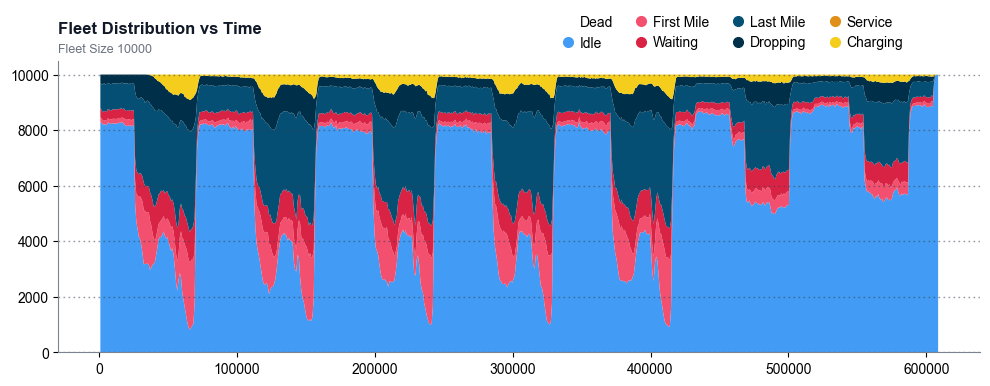

In [30]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(fleet_output.index, fleet_output.T,
             labels=[styles[c].label for c in fleet_output.columns],
             colors=[styles[c].color for c in fleet_output.columns])

handles = [
    Line2D([0], [0], marker="o", markersize=7,
           markerfacecolor=styles[c].color, markeredgecolor=styles[c].color, label=styles[c].label)
    for i, c in enumerate(fleet_output.columns)
]
ax.legend(handles=handles, bbox_to_anchor=(0.93, 1.2), ncol=4, frameon=False, handlelength=0.1)

style_plot(ax, title="Fleet Distribution vs Time", subtitle=f"Fleet Size {fleet_size}")
plt.show()

In [ ]:
plot_evolving_histograms(output[["response_time", "fm_time", "lm_time"]] / 60, output["start_at"] / 3600, styles,
                         title="Ann Arbor EV Simulation", k=6, subtitle="Distribution of Time Metrics")

# Response Time (request time -> pickup time)
# FM - first mile (previous drop -> pickup time)
# LM - last mile (pickup -> drop time)

# + 4 minutes for pickup/drop

In [ ]:
plot_evolving_histograms(output[["fm_dist", "lm_dist", "predicted_lm_dist"]] / 1.68, output["start_at"] / 3600, styles,
                         title="Ann Arbor EV Simulation", subtitle="Distribution of Distances", k=6)

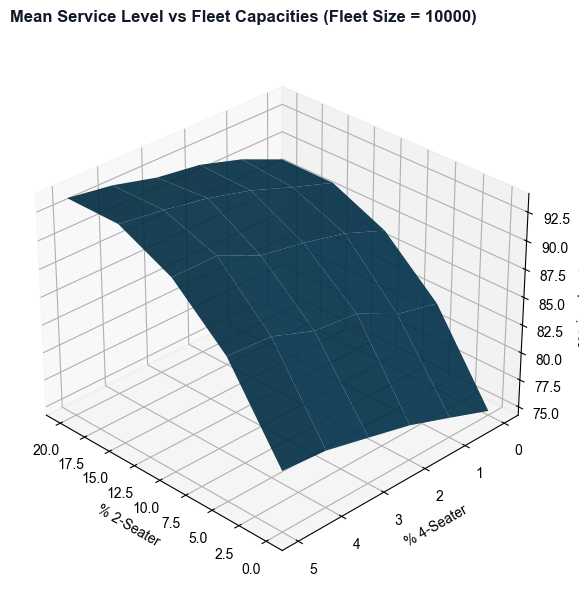

In [128]:
key = "service_level"
fleet_size = 10000

Z = np.empty((len(FRAC_4_SEATER), len(FRAC_2_SEATER)))

for i, pax4 in enumerate(FRAC_4_SEATER):
    for j, pax2 in enumerate(FRAC_2_SEATER):
        all_output, output, fleet_output = load_results(REQUESTS_FILE, f"output/ann-arbor-{fleet_size}-{pax2}-{pax4}")
        Z[i, j] = compute_stats(all_output, output)[key]

X, Y = np.meshgrid(FRAC_2_SEATER, FRAC_4_SEATER)
X *= 100
Y *= 100

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=30, azim=135)

ax.plot_surface(X, Y, Z, alpha=0.9, color=styles[key].color)

ax.set_xlabel("% 2-Seater")
ax.set_ylabel("% 4-Seater")
ax.set_zlabel(key)

style_plot(ax, title=f"Mean {styles[key].label} vs Fleet Capacities (Fleet Size = {fleet_size})")